In [2]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

%cd /content
!git clone https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git

%cd /content/Auto-insurance-claim-frequency
!git config user.email "basseysamuel404@gmail.com"
!git config user.name "Bassey-data"

print("Setup complete")

/content
Cloning into 'Auto-insurance-claim-frequency'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 13 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 5.36 KiB | 1.79 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Auto-insurance-claim-frequency
Setup complete


In [3]:
pip install statsmodels liac-arff lightgbm pyarrow shap

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=0f1dc3e022d47f6ec3935a051739c5ced866bc06d6e09428f4886b792622c165
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


Import all useful modules

In [4]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings("ignore")


In [5]:
# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [6]:
def parse_arff(path):
    columns = []
    data_start = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.lower().startswith("@attribute"):
            parts = stripped.split(maxsplit=2)
            columns.append(parts[1])
        elif stripped.lower().startswith("@data"):
            data_start = i + 1
            break

    data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

    rows = []
    for line in data_lines:
        values = [v.strip().strip("'").strip('"') for v in line.split(",")]
        rows.append(values)

    return pd.DataFrame(rows, columns=columns)


df = parse_arff("/content/drive/MyDrive/ACQsci.arff")

print(df.head())

  IDpol ClaimNb Exposure Area VehPower VehAge DrivAge BonusMalus VehBrand  \
0     1       1      0.1    D        5      0      55         50      B12   
1     3       1     0.77    D        5      0      55         50      B12   
2     5       1     0.75    B        6      2      52         50      B12   
3    10       1     0.09    B        7      0      46         50      B12   
4    11       1     0.84    B        7      0      46         50      B12   

    VehGas Density Region  
0  Regular    1217    R82  
1  Regular    1217    R82  
2   Diesel      54    R22  
3   Diesel      76    R72  
4   Diesel      76    R72  


In [7]:
df.dtypes

,0
IDpol,object
ClaimNb,object
Exposure,object
Area,object
VehPower,object
VehAge,object
DrivAge,object
BonusMalus,object
VehBrand,object
VehGas,object


fix numeric and categorical columns data types

In [8]:
# used an f string for readable output
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (678013, 12)

Missing values:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

Duplicate rows: 0


In [9]:
df_converted = df.apply(pd.to_numeric, errors="ignore")

for col in df_converted.select_dtypes(include="object").columns:
    df_converted[col] = df_converted[col].astype("category")

df = df_converted
print(df.dtypes)

IDpol          float64
ClaimNb          int64
Exposure       float64
Area          category
VehPower         int64
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas        category
Density          int64
Region        category
dtype: object


In [10]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (678013, 12)

Missing values:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

Duplicate rows: 0


In [11]:
os.makedirs("data/processed", exist_ok=True)

df.to_parquet("data/processed/freMTPL2freq.parquet", index=False)

print("Saved successfully")
print(f"Parquet size: {os.path.getsize('data/processed/freMTPL2freq.parquet') / 1e6:.1f} MB")

Saved successfully
Parquet size: 7.5 MB


In [12]:
print(os.path.exists("/content/Auto-insurance-claim-frequency/data/processed/freMTPL2freq.parquet"))


True


In [13]:
%cd /content/Auto-insurance-claim-frequency
!git add .
!git commit -m "Add data preparation notebook and processed parquet file"
!git push

/content/Auto-insurance-claim-frequency
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [14]:
%cd /content/Auto-insurance-claim-frequency
!ls -la
!ls -la data/processed/
!ls -la notebooks/ sce

/content/Auto-insurance-claim-frequency
total 28
drwxr-xr-x 5 root root 4096 Jul  6 12:12 .
drwxr-xr-x 1 root root 4096 Jul  6 12:12 ..
drwxr-xr-x 4 root root 4096 Jul  6 12:12 data
drwxr-xr-x 8 root root 4096 Jul  6 12:13 .git
-rw-r--r-- 1 root root  166 Jul  6 12:12 .gitignore
drwxr-xr-x 2 root root 4096 Jul  6 12:12 notebooks
-rw-r--r-- 1 root root  107 Jul  6 12:12 README.md
total 7304
drwxr-xr-x 2 root root    4096 Jul  6 12:13 .
drwxr-xr-x 4 root root    4096 Jul  6 12:12 ..
-rw-r--r-- 1 root root 7468412 Jul  6 12:13 freMTPL2freq.parquet
-rw-r--r-- 1 root root       0 Jul  6 12:12 .gitkeep
ls: cannot access 'sce': No such file or directory
notebooks/:
total 24
drwxr-xr-x 2 root root  4096 Jul  6 12:12 .
drwxr-xr-x 5 root root  4096 Jul  6 12:12 ..
-rw-r--r-- 1 root root 14686 Jul  6 12:12 01_data_prep.ipynb


In [15]:
%cd /content/Auto-insurance-claim-frequency

# Create notebooks folder and copy notebook into it
!mkdir -p notebooks
!cp "/content/drive/MyDrive/Colab Notebooks/Insurance_claim.ipynb" notebooks/01_data_prep.ipynb

# The parquet is gitignored which is correct - data files shouldn't be on GitHub
# Let's confirm notebooks got copied
!ls notebooks/

/content/Auto-insurance-claim-frequency
01_data_prep.ipynb


In [16]:
!git add notebooks/
!git commit -m "Add data preparation notebook"
!git push

[main f722fb1] Add data preparation notebook
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/01_data_prep.ipynb (94%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 2.07 KiB | 1.04 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Bassey-data/Auto-insurance-claim-frequency.git
   62b2cbc..f722fb1  main -> main


In [17]:
df = pd.read_parquet("/content/Auto-insurance-claim-frequency/data/processed/freMTPL2freq.parquet")
print(df.shape)
print(df.head())

(678013, 12)
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand   VehGas  Density Region  
0      B12  Regular     1217    R82  
1      B12  Regular     1217    R82  
2      B12   Diesel       54    R22  
3      B12   Diesel       76    R72  
4      B12   Diesel       76    R72  


Check total clims and total exposure and calculate portfolio frequency

In [18]:
total_claims = df["ClaimNb"].sum()
total_exposure = df["Exposure"].sum()
portfolio_frequency = total_claims / total_exposure

print(f"Total claims: {total_claims:,}")
print(f"Total exposure (policy-years): {total_exposure:,.1f}")
print(f"Portfolio frequency: {portfolio_frequency:.4f} claims per policy-year")

Total claims: 36,102
Total exposure (policy-years): 358,499.4
Portfolio frequency: 0.1007 claims per policy-year


Check claim distribution

In [19]:
claim_counts = df["ClaimNb"].value_counts().sort_index()
print(claim_counts)
print()
print(f"Policies with zero claims: {(df['ClaimNb'] == 0).mean() * 100:.2f}%")

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

Policies with zero claims: 94.98%


Visualize using log scale

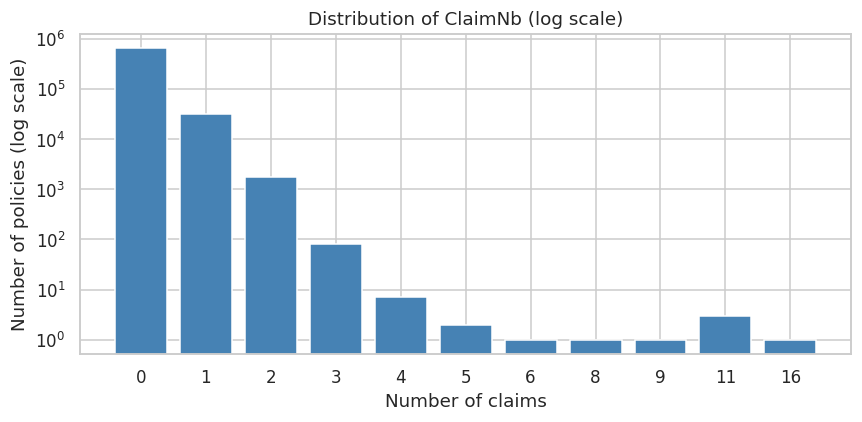

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(claim_counts.index.astype(str), claim_counts.values, color="steelblue")
ax.set_yscale("log")
ax.set_title("Distribution of ClaimNb (log scale)")
ax.set_xlabel("Number of claims")
ax.set_ylabel("Number of policies (log scale)")

plt.tight_layout()
plt.show()

Exposure plot

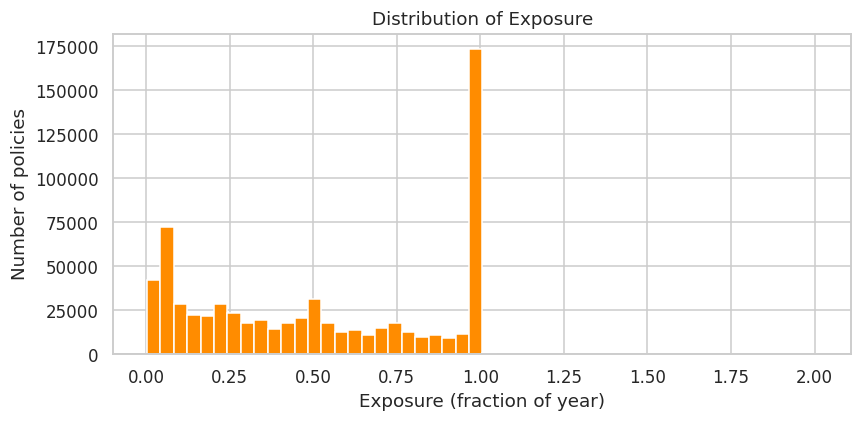

Min exposure: 0.0027322404371584
Max exposure: 2.01
Policies with Exposure > 1: 1224


In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df["Exposure"], bins=50, color="darkorange")
ax.set_title("Distribution of Exposure")
ax.set_xlabel("Exposure (fraction of year)")
ax.set_ylabel("Number of policies")

plt.tight_layout()
plt.show()

print(f"Min exposure: {df['Exposure'].min()}")
print(f"Max exposure: {df['Exposure'].max()}")
print(f"Policies with Exposure > 1: {(df['Exposure'] > 1).sum()}")